# Questions


In [ ]:
1) Load the given dataset 
2) Fill Null value of children column with the value 0 
3) Replace the Null values of the column BMI with mean value 
4) Display a scatter plot between age and children
5) Display bar plot between BMI and children 
6) Perform encoding to convert character data into numerical data 
7) Perform scaling
model 
1) Separate feature data from target data 
2) Create a Linear regression model between Features and target data
3) Display the test score and training score
4) Extract slope and intercept value from the model 
5) Display Mean Squared Error 
6) Display Mean Absolute Error 
7) Display Root mean Squared error 
8) Display R2 score

# 1) Load the given dataset 

In [1]:
import pandas as pd

In [2]:
cd C:\Users\dell\OneDrive\Desktop\Finger Tips\Machine learning\Projects\Projects datafile

C:\Users\dell\OneDrive\Desktop\Finger Tips\Machine learning\Projects\Projects datafile


In [3]:
data =pd.read_csv("ML Linear Regression Insurance Prediction.txt")

In [4]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 2) Fill Null value of children column with the value 0 

In [5]:
data["children"] = data["children"].fillna(0)

# 3) Replace the Null values of the column BMI with mean value 

In [6]:
data["bmi"].mean()

np.float64(30.66339686098655)

In [7]:
data["bmi"] = data["bmi"].fillna(30.663)

# 4) Display a scatter plot between age and children

In [8]:
import matplotlib.pyplot as plt

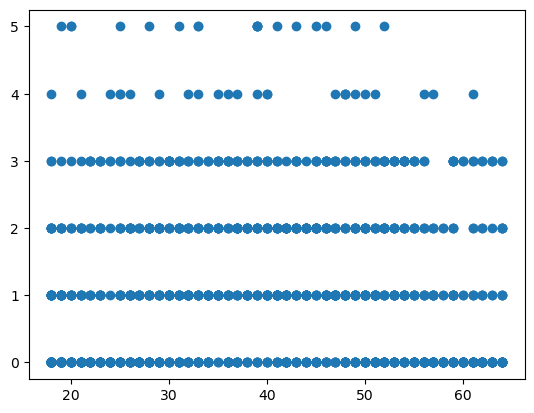

In [9]:
plt.scatter(data["age"],data["children"])

# 5) Display bar plot between BMI and children 

# 6) Perform encoding to convert character data into numerical data 

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1338 non-null   float64
 1   bmi        1338 non-null   float64
 2   children   1338 non-null   float64
 3   charges    1338 non-null   float64
 4   northeast  1338 non-null   bool   
 5   northwest  1338 non-null   bool   
 6   southeast  1338 non-null   bool   
 7   southwest  1338 non-null   bool   
 8   female     1338 non-null   bool   
 9   male       1338 non-null   bool   
 10  no         1338 non-null   bool   
 11  yes        1338 non-null   bool   
dtypes: bool(8), float64(4)
memory usage: 52.4 KB


In [11]:
data["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [12]:
region = pd.get_dummies(data["region"])

In [13]:
data["sex"].unique()

array(['female', 'male'], dtype=object)

In [14]:
sex = pd.get_dummies(data["sex"])

In [15]:
data["smoker"].unique()

array(['yes', 'no'], dtype=object)

In [16]:
smoker = pd.get_dummies(data["smoker"])

In [17]:
data.drop(["sex","smoker","region"] , axis = 1, inplace = True)

In [18]:
data = pd.concat ( [data, region , sex , smoker ] , axis=1 )

# 7) Perform scaling

In [ ]:
data.describe()

In [19]:
from sklearn.preprocessing import StandardScaler,RobustScaler

In [20]:
scaler = StandardScaler()

In [21]:
data[["age","bmi"]] = scaler.fit_transform(data[["age","bmi"]])

In [22]:
data["children"] = scaler.fit_transform(data[["children"]])

# 1) Separate feature data from target data 

In [24]:
x=data.drop("charges",axis=1)
y=data["charges"]

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# 2) Create a Linear regression model between Features and target data

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
model = LinearRegression()

In [29]:
model.fit(x_train,y_train)

LinearRegression()

# 3) Display the test score and training score

In [30]:
model.score(x_train,y_train)

0.7417255854683333

In [31]:
model.score(x_test,y_test)

0.7835929767120723

# 4) Extract slope and intercept value from the model 

In [32]:
(model.coef_)

array([ 3.60914902e+03,  2.05488506e+03,  5.12478869e+02,  4.59585244e+02,
        8.89079180e+01, -1.98279052e+02, -3.50214110e+02,  9.29584582e+00,
       -9.29584582e+00, -1.18255644e+04,  1.18255644e+04])

In [33]:
model.intercept_

np.float64(20302.765320157287)

# 5) Display Mean Squared Error 

In [34]:
from sklearn.metrics import r2_score,root_mean_squared_error,mean_squared_error , mean_absolute_error

In [35]:
y_predict = model.predict(x_test)

In [36]:
mean_squared_error(y_test,y_predict)

33596915.85136146

# 6) Display Mean Absolute Error 

In [37]:
mean_absolute_error(y_test,y_predict)

4181.1944737536505

# 7) Display Root mean Squared error 

In [38]:
r2_score(y_test,y_predict)

0.7835929767120723

# 8) Display R2 score

In [39]:
root_mean_squared_error(y_test,y_predict)

5796.2846592762735

# Lasso

In [40]:
from sklearn.linear_model import Lasso

In [41]:
model1 = Lasso()

In [42]:
model1.fit(x_train,y_train)

Lasso()

In [43]:
yp1 = model1.predict(x_test)

In [44]:
r2_score(y_test,yp1)

0.7835354782260755

In [47]:
model1.score(x_train,y_train)

0.7417253659097784

In [49]:
model1.score(x_test,y_test)

0.7835354782260755